# Este proyecto analiza los datos de postulantes a Beca 18 Ordinaria con el objetivo de identificar patrones asociados a la selección.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_seleccionados = pd.read_csv("../data/postulantes_seleccionados.csv")
df_no_seleccionados = pd.read_csv("../data/postulantes_no_seleccionados.csv")

df = pd.concat([df_seleccionados,df_no_seleccionados],  ignore_index=True)

In [2]:
#Limpiamos las columnas importantes
df_limpio = df[["MODALIDAD_BECA", "IES","CARRERA","PUNTAJE_FINAL","CONDICION"]]

#Trabajaremos con solo la modalidad ordinaria
df_limpio = df_limpio[df_limpio["MODALIDAD_BECA"]=="BECA 18 ORDINARIA"]

#Codificando
le = LabelEncoder()
df_limpio["CONDICION_ENCODING"] = le.fit_transform(df_limpio["CONDICION"])

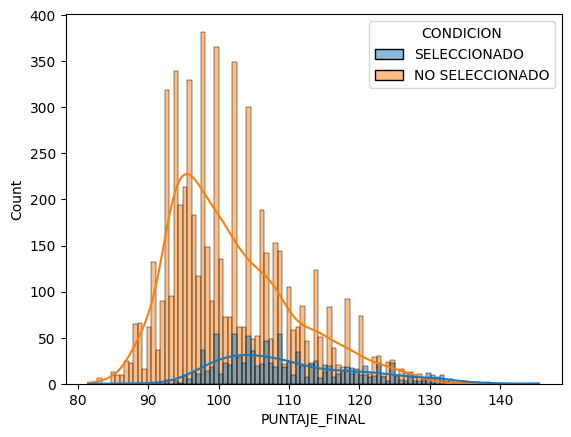

In [3]:
sns.histplot(data=df_limpio, x="PUNTAJE_FINAL", hue="CONDICION", kde=True, bins=100)
plt.show()

# La distribución de los puntajes finales en ambos grupos presenta un comportamiento sesgado hacia la derecha, con una mayor concentración de valores entre aproximadamente 80 y 110 puntos.
# Si bien los postulantes seleccionados tienden a presentar puntajes más altos en promedio, existe un notable solapamiento entre ambas distribuciones. En particular, se identifican numerosos casos de postulantes no seleccionados con puntajes iguales o incluso superiores a los de algunos seleccionados.
# Este hallazgo sugiere que, aunque el puntaje final es un factor relevante en el proceso de selección, no es el único determinante. La evidencia apunta a la influencia de otros criterios, como la priorización de ciertos tipos de instituciones educativas (IES), que pueden explicar la selección de postulantes con puntajes relativamente menores.

,count,mean,std,min,25%,50%,75%,max
CONDICION,,,,,,,,
NO SELECCIONADO,6311.0,101.665505,8.718678,81.5,95.0,100.0,106.5,135.0
SELECCIONADO,1078.0,110.105751,9.764637,89.0,102.5,108.0,117.0,145.5


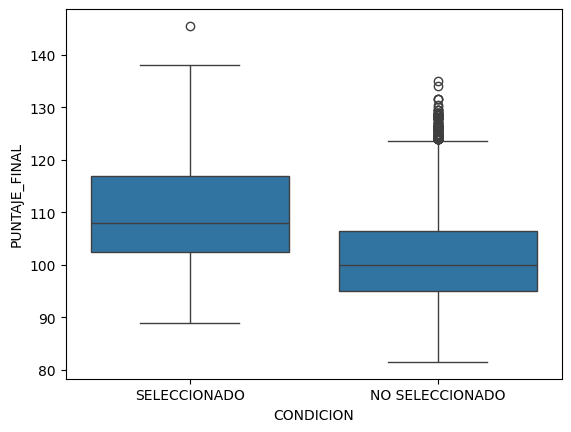

In [4]:
sns.boxplot(data=df_limpio, x="CONDICION", y="PUNTAJE_FINAL")
df_limpio.groupby("CONDICION")["PUNTAJE_FINAL"].describe()


<!-- El análisis mediante boxplot muestra que los postulantes seleccionados presentan una mediana de puntaje superior a la de los no seleccionados (106.5 vs 98), lo que confirma que el puntaje final es un factor relevante en el proceso de selección.

Sin embargo, se observa un importante solapamiento entre ambos grupos, incluyendo múltiples casos de postulantes no seleccionados con puntajes superiores a los de algunos seleccionados. Esto sugiere que el puntaje no es el único criterio determinante.

Asimismo, la presencia de numerosos outliers en el grupo de no seleccionados con puntajes altos refuerza la hipótesis de que existen criterios adicionales de priorización, como el tipo de institución (por ejemplo, preferencia por instituciones nacionales), que influyen en la asignación de becas.  -->


# El análisis mediante boxplot del puntaje final de seleccionados vs no seleccionados, evidencia que los postulantes seleccionados presentan, en promedio, valores significativamente superiores a los no seleccionados, con una diferencia aproximada de 8 puntos tanto en la media como en la mediana.
# Asimismo, la presencia de numerosos outliers (outlider: Valor atípico que está muy lejos del resto de los datos.) en el grupo de no seleccionados refuerza la hipótesis de que existen criterios adicionales de priorización, como el tipo de institución (por ejemplo, preferencia por instituciones nacionales), que influyen en la asignación de becas.

In [5]:
tabla_seleccionados = df_limpio.groupby("IES")["CONDICION_ENCODING"].agg(["sum","count"])
tabla_seleccionados= tabla_seleccionados.rename(columns={"sum": "Seleccionados",
                                                        "count": "Total" })

tabla_seleccionados["ratio"] = tabla_seleccionados["Seleccionados"] / tabla_seleccionados["Total"]

tabla_seleccionados.sort_values("Seleccionados", ascending=False).head(20)

,Seleccionados,Total,ratio
IES,,,
UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO,120,120,1.000000
UNIVERSIDAD NACIONAL DE INGENIERIA,94,94,1.000000
UNIVERSIDAD NACIONAL MAYOR DE SAN MARCOS,83,83,1.000000
SERVICIO NACIONAL DE ADIESTRAMIENTO EN TRABAJO INDUSTRIAL - SENATI,72,94,0.765957
UNIVERSIDAD NACIONAL DE SAN AGUSTIN DE AREQUIPA,58,58,1.000000
UNIVERSIDAD NACIONAL DE PIURA,55,55,1.000000
UNIVERSIDAD NACIONAL HERMILIO VALDIZAN,50,50,1.000000
UNIVERSIDAD NACIONAL DEL ALTIPLANO,48,48,1.000000
IES PRIVADO TECSUP N° 1,38,42,0.904762


# Existe una fuerte concentración de seleccionados en universidades nacionales, muchas de las cuales presentan tasas cercanas al 100%, lo que sugiere una priorización clara de este tipo de instituciones.
# Asimismo, se observa la participación del instituto técnico TECSUP, lo que indica que la formación técnica también es considerada dentro del proceso de asignación.
# En conjunto, estos resultados refuerzan la idea de que el tipo de institución educativa tiene un peso determinante en la selección, más allá del puntaje en ciertos casos.

# El análisis de los datos de postulantes a Beca 18 Ordinaria evidencia que los seleccionados presentan, en promedio, puntajes finales superiores a los no seleccionados, con una diferencia aproximada de 8 puntos.
# No obstante, se observa un solapamiento considerable entre ambos grupos, incluyendo casos de postulantes no seleccionados con puntajes iguales o incluso mayores que algunos seleccionados.
# Este comportamiento indica que el puntaje final, si bien es un factor relevante, no constituye un criterio determinante en el proceso de selección.
# Asimismo, el análisis por institución educativa revela una alta concentración de seleccionados en determinadas IES, particularmente en universidades nacionales, muchas de las cuales presentan tasas cercanas al 100% de selección.
# En conjunto, los resultados sugieren que el proceso de selección responde a una combinación de factores, donde el puntaje académico es importante, pero no suficiente para explicar completamente la asignación de becas.